# Full pipeline

Data prep -> train base/sft_only/distilled -> evaluate -> layer analysis.

**Resumable.** Every stage is skipped if it already finished, and each finished stage is saved to a private Hugging Face repo, so a run that stops (quota, crash, session limit) continues from that point next time, even in a new session or account.

One-time setup: create a Hugging Face token with write access, then in this notebook open Add-ons -> Secrets, add a secret named `HF_TOKEN`, and attach it. Never paste a token into a notebook cell. While the GitHub repo is private, also add a secret `GH_TOKEN` (a GitHub token with read access to the repo), otherwise the clone fails immediately. To force a from-scratch run (for example after a code fix that changes training), change `ADBENCH_RUN_TAG` in the first code cell.

Enable GPU first (Kaggle: Accelerator -> GPU T4 x2, Internet -> On). Rough timing on T4 x2: data prep ~2 min, training ~40 min total, evaluation ~1-2 h, layer analysis ~20 min. The guard cell after training stops the run early if a trained model does not emit clean tool calls.


In [1]:
import base64
import os
import subprocess
import sys

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Kaggle secrets (Add-ons -> Secrets), all optional:
#   GH_TOKEN  read access to the GitHub repo, needed only while the repo is private
#   HF_TOKEN  write access to a Hugging Face repo, needed only to resume across sessions
os.environ.setdefault('ADBENCH_HF_REPO', 'NahlaNabil/adbench-run')
os.environ.setdefault('ADBENCH_RUN_TAG', 'v1-fixed')
try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _name in ('GH_TOKEN', 'HF_TOKEN'):
        try:
            os.environ[_name] = _secrets.get_secret(_name)
        except Exception:
            pass
except Exception:
    pass


def git(*args, timeout=600):
    """Run git without ever prompting (a credentials prompt would hang an unattended run for
    hours). Uses GH_TOKEN when set; if that fails (revoked token, or a public repo that needs
    none) it retries once without it."""
    env = {**os.environ, 'GIT_TERMINAL_PROMPT': '0'}
    token = os.environ.get('GH_TOKEN')
    for use_token in ([True, False] if token else [False]):
        cmd = ['git']
        if use_token:
            basic = base64.b64encode(f"x-access-token:{token}".encode()).decode()
            cmd += ['-c', f'http.https://github.com/.extraheader=AUTHORIZATION: basic {basic}']
        try:
            subprocess.run(cmd + list(args), check=True, timeout=timeout, env=env)
            return
        except subprocess.CalledProcessError:
            if not use_token:
                raise
            print('git with GH_TOKEN failed; retrying without it.')


def run_module(*args, timeout=4 * 3600):
    """Run `python -m <args>` in a fresh process, print the tail of its output, and raise if it
    fails or exceeds `timeout` seconds (a bare `!` command never stops the notebook)."""
    proc = subprocess.run(
        [sys.executable, '-m', *args], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, timeout=timeout
    )
    print(proc.stdout[-20000:])
    proc.check_returncode()


ON_KAGGLE = os.path.isdir('/kaggle')
REPO_DIR = '/kaggle/working/agentic-distillation-benchmark' if ON_KAGGLE else '/content/agentic-distillation-benchmark'

if not os.path.isdir(REPO_DIR):
    git('clone', 'https://github.com/Nahla-Nabil/agentic-distillation-benchmark.git', REPO_DIR)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements-colab.txt'], check=True, timeout=1800)

src_path = os.path.join(REPO_DIR, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
os.environ['PYTHONPATH'] = src_path + os.pathsep + os.environ.get('PYTHONPATH', '')


Cloning into '/kaggle/working/agentic-distillation-benchmark'...
fatal: could not read Username for 'https://github.com': terminal prompts disabled
Cloning into '/kaggle/working/agentic-distillation-benchmark'...


git with GH_TOKEN failed; retrying without it.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 14.2 MB/s eta 0:00:00
  

In [2]:
# re-sync to the latest commit
git('-C', REPO_DIR, 'checkout', '--', '.')
git('-C', REPO_DIR, 'pull')

fatal: could not read Username for 'https://github.com': terminal prompts disabled


git with GH_TOKEN failed; retrying without it.
Already up to date.


In [3]:
from adbench import pipeline_state as ps

ps.restore()
ps.check_upload()

[persist] could not restore from NahlaNabil/adbench-run: RepositoryNotFoundError: 404 Client Error. (Request ID: Root=1-6aae9410-214268da6bb95a1b32390275;2c64712c-8bda-4acb-a13d-b9951fc9ed93)

Repository Not Found for url: https://huggingface.co/api/models/NahlaNabil/adbench-run/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication. Starting fresh.
[persist] ON — write access to NahlaNabil/adbench-run confirmed (tag 'v1-fixed').


## 1. Data

In [4]:
def prepare_data():
    run_module("adbench.data.prepare", "--config", "configs/data.yaml")
    run_module("adbench.data.general_eval", "--config", "configs/experiment.yaml")


ps.run_stage("data", prepare_data)

[stage] data: running ...
Loading glaiveai/glaive-function-calling-v2 ...

Generating train split: 100%|██████████| 112960/112960 [00:02<00:00, 53519.54 examples/s]
Loaded 112960 raw rows.
  ...0/112960
  ...20000/112960
  ...40000/112960
  ...60000/112960
  ...80000/112960
  ...100000/112960

=== prepare.py summary ===
raw rows processed: 112960
drop reasons: {'zero_calls': 49742, 'multi_call': 19583, 'tool_not_selected': 29073, 'ok': 10126, 'non_canonical_args': 3437, 'parse_error': 999}
distinct tool names seen in raw data: 966
kept examples per selected tool (before the per-tool cap):
  calculate_age: 1722
  calculate_bmi: 2946
  calculate_discount: 1852
  calculate_distance: 189
  calculate_tip: 1913
  convert_currency: 1081
  generate_random_number: 240
  get_stock_price: 183
train: 640   test: 160   total: 800
wrote: /kaggle/working/agentic-distillation-benchmark/data/splits/train.jsonl
wrote: /kaggle/working/agentic-distillation-benchmark/data/splits/test.jsonl
wrote: /kaggle/w

True

## 2. Training

In [5]:
ps.run_stage("train_base", lambda: run_module("adbench.training.train", "--condition", "base"))

[stage] train_base: running ...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

Loading weights: 100%|██████████| 398/398 [00:01<00:00, 206.25it/s]
Unsloth 2026.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/base/tokenizer_config.json.
{
  "condition": "base",
  "checkpoint_dir": "/kaggle/working/agentic-distillation-benc

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage train_base)


True

Early check: layer analysis on the teacher and the base student, right after the first checkpoint exists. This stage has never run on a GPU before, so any problem in it shows up here instead of hours later. Each model is extracted in its own fresh process (Unsloth patches transformers globally on import, which breaks student hooks if it was already imported).

In [6]:
ps.run_stage("layer_teacher", lambda: run_module("adbench.analysis.layer_analysis", "--role", "teacher"))

[stage] layer_teacher: running ...
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1568: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

Loading we

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage layer_teacher)


True

In [7]:
ps.run_stage(
    "layer_student_base",
    lambda: run_module("adbench.analysis.layer_analysis", "--role", "student", "--condition", "base"),
)

[stage] layer_student_base: running ...
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).

Fetching 3 files: 100%|██████████| 3/3 [00:30<00:00, 10.16s/it]

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 142.62it/s]
student: 36 layers



Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage layer_student_base)


True

In [8]:
run_module("adbench.analysis.layer_analysis", "--role", "compare")

compared base: teacher 40 layers, student 36 layers
skipping sft_only: no cached student activations
skipping distilled: no cached student activations
144 rows written to results/layer_analysis/divergence.jsonl



In [9]:
ps.run_stage("train_sft_only", lambda: run_module("adbench.training.train", "--condition", "sft_only"))

[stage] train_sft_only: running ...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

Loading weights: 100%|██████████| 398/398 [00:17<00:00, 23.25it/s]
Unsloth 2026.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
`use_return_dict` is deprecated! Use `return_dict` instead!
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/sft_only/tokenizer_config.json.
{
  "condition": "sf

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage train_sft_only)


True

In [10]:
ps.run_stage("train_distilled", lambda: run_module("adbench.training.train", "--condition", "distilled"))

[stage] train_distilled: running ...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

Loading weights: 100%|██████████| 398/398 [00:01<00:00, 208.92it/s]
Unsloth 2026.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Tr

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage train_distilled)


True

Guard: stop the run now if a trained model does not produce clean tool calls, before the long evaluation.

In [11]:
def guard():
    for condition in ["sft_only", "distilled"]:
        run_module("adbench.evaluation.diagnose", "--condition", condition,
                   "--skip-training-target", "--n", "5", "--require-tool-call", "--max-failures", "1")


ps.run_stage("guard", guard)

[stage] guard: running ...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.166 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.95 GiB  weights  1.760 GiB  free 11.192 GiB  reserve 11.166 GiB
  cuda:1  budget  13.00 GiB  weights  1.497 GiB  free 11.499 GiB  rese

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage guard)


True

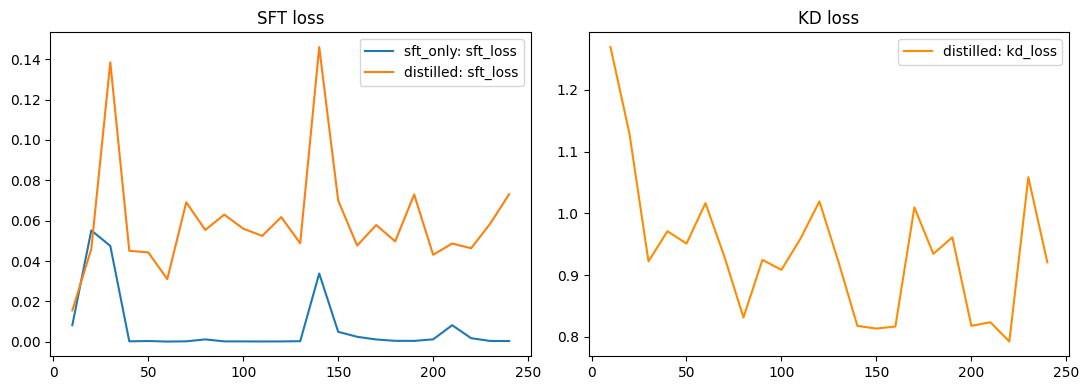

In [12]:
import matplotlib.pyplot as plt

from adbench.data.prepare import read_jsonl
from adbench.training.train import loss_log_path

sft_log = read_jsonl(loss_log_path("sft_only"))
distilled_log = read_jsonl(loss_log_path("distilled"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([r["step"] for r in sft_log], [r["sft_loss"] for r in sft_log], label="sft_only: sft_loss")
axes[0].plot([r["step"] for r in distilled_log], [r["sft_loss"] for r in distilled_log], label="distilled: sft_loss")
axes[0].set_title("SFT loss")
axes[0].legend()

axes[1].plot([r["step"] for r in distilled_log], [r["kd_loss"] for r in distilled_log], label="distilled: kd_loss", color="darkorange")
axes[1].set_title("KD loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Evaluation

In [13]:
import json

from adbench.evaluation.run_eval import evaluate_condition, write_eval_outputs
from adbench.training.train import CONDITIONS, REPO_ROOT, load_experiment_config

experiment_config = load_experiment_config("configs/experiment.yaml")
models_config = load_experiment_config("configs/models.yaml")
chain_lengths = experiment_config["harness"]["chain_lengths"]

all_rows = []
perplexities = {}
for condition in CONDITIONS:
    stage = f"eval_{condition}"
    cache_file = ps.stages_dir() / f"{stage}.json"
    if ps.is_done(stage) and cache_file.exists():
        saved = json.loads(cache_file.read_text(encoding="utf-8"))
        rows, perplexity = saved["rows"], saved["perplexity"]
        print(f"=== {condition}: restored from an earlier run ===")
    else:
        print(f"=== Evaluating {condition} ===")
        rows, perplexity = evaluate_condition(condition, experiment_config, models_config, chain_lengths)
        ps.stages_dir().mkdir(parents=True, exist_ok=True)
        cache_file.write_text(json.dumps({"rows": rows, "perplexity": perplexity}), encoding="utf-8")
        ps.finish(stage)
    all_rows.extend(rows)
    perplexities[condition] = perplexity
    print(f"{condition}: {len(rows)} tasks, perplexity={perplexity:.2f}")
    output = write_eval_outputs(all_rows, perplexities, REPO_ROOT / "results")

print("wrote results/eval_results.jsonl, eval_results.csv, eval_summary.json")

=== Evaluating base ===
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.7: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.257 GiB
no_split classes   : ['Qwen3DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.166 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.95 GiB  weights  1.760 GiB  free 11.192 GiB  reserve 11.166 GiB
  cuda:1  budget  13.00 GiB  weights  1.497 GiB  free 11.499 GiB  reserve

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Unsloth 2026.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
`use_return_dict` is deprecated! Use `return_dict` instead!


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage eval_distilled)
distilled: 121 tasks, perplexity=18.46
wrote results/eval_results.jsonl, eval_results.csv, eval_summary.json


In [14]:
import pandas as pd

summary_df = pd.DataFrame(output["summary"])
summary_df[["condition", "chain_length", "n_tasks", "full_chain_success_rate",
            "per_step_success_rate", "clean_step_success_rate", "recovery_rate", "perplexity"]]

,condition,chain_length,n_tasks,full_chain_success_rate,per_step_success_rate,clean_step_success_rate,recovery_rate,perplexity
0,base,1,46,0.934783,0.934783,0.739130,0.750000,18.307116
1,base,3,40,0.700000,0.899160,0.680672,0.700000,18.307116
2,base,5,35,0.742857,0.944785,0.889571,0.750000,18.307116
3,distilled,1,46,1.000000,1.000000,0.739130,1.000000,18.461749
4,distilled,3,40,0.875000,0.957627,0.703390,0.800000,18.461749
5,distilled,5,35,0.914286,0.982143,0.863095,0.888889,18.461749
6,sft_only,1,46,0.956522,0.956522,0.739130,0.833333,17.350724
7,sft_only,3,40,0.700000,0.896552,0.793103,0.400000,17.350724
8,sft_only,5,35,0.685714,0.929936,0.898089,0.625000,17.350724


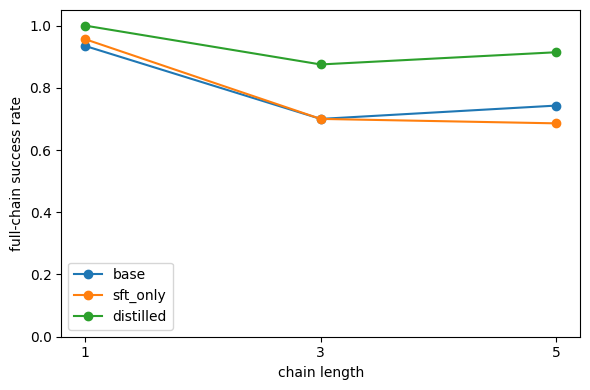

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
for condition in CONDITIONS:
    sub = summary_df[summary_df["condition"] == condition].sort_values("chain_length")
    ax.plot(sub["chain_length"], sub["full_chain_success_rate"], marker="o", label=condition)
ax.set_xlabel("chain length")
ax.set_ylabel("full-chain success rate")
ax.set_xticks(chain_lengths)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
from adbench.evaluation.metrics import error_category_breakdown

for condition in CONDITIONS:
    condition_rows = [r for r in all_rows if r["condition"] == condition]
    print(condition, error_category_breakdown(condition_rows))

base {'protocol': 24}
sft_only {'protocol': 25}
distilled {'protocol': 8}


## 4. Layer analysis (remaining students)


The teacher and the base student were already extracted above. Here: the two trained students, then compare all conditions and plot.


In [17]:
for condition in ["sft_only", "distilled"]:
    ps.run_stage(
        f"layer_student_{condition}",
        lambda condition=condition: run_module(
            "adbench.analysis.layer_analysis", "--role", "student", "--condition", condition
        ),
    )

[stage] layer_student_sft_only: running ...
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).

Loading weights: 100%|██████████| 398/398 [00:39<00:00,  9.96it/s]
student: 36 layers



Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (stage layer_student_distilled)


Compare + plot

In [18]:
run_module("adbench.analysis.layer_analysis", "--role", "compare")
ps.push("layer analysis results")

compared base: teacher 40 layers, student 36 layers
compared sft_only: teacher 40 layers, student 36 layers
compared distilled: teacher 40 layers, student 36 layers
432 rows written to results/layer_analysis/divergence.jsonl



Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


[persist] saved to NahlaNabil/adbench-run (layer analysis results)


True

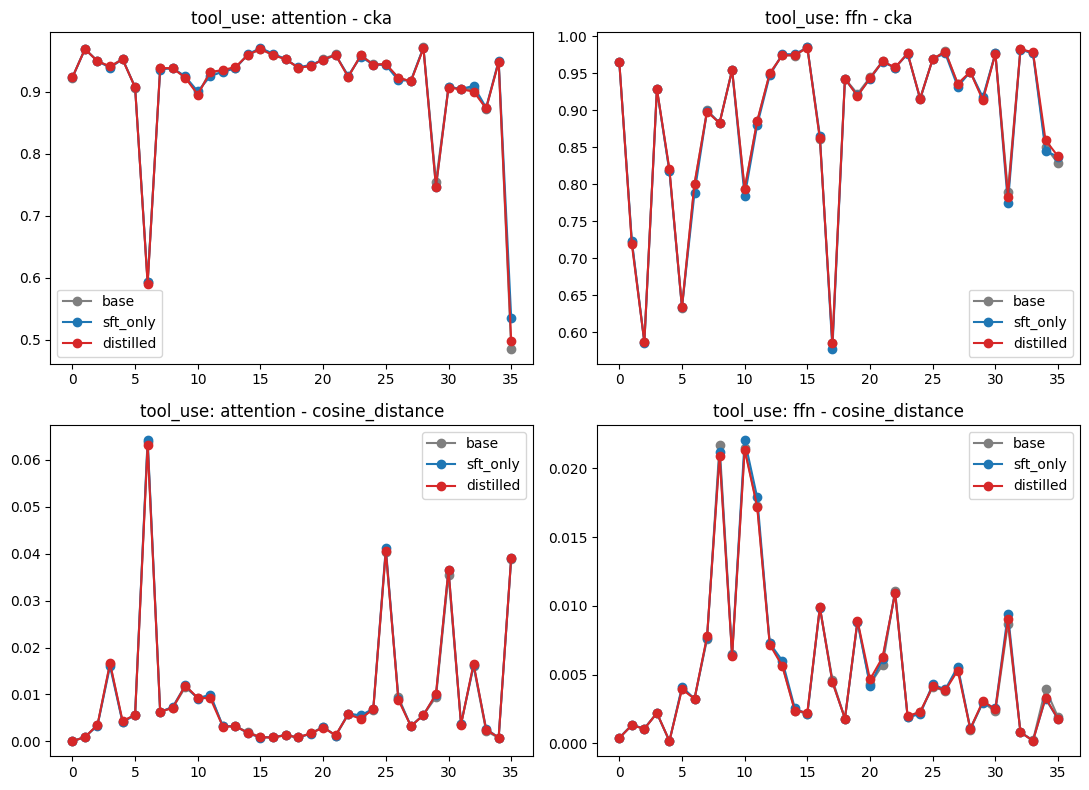

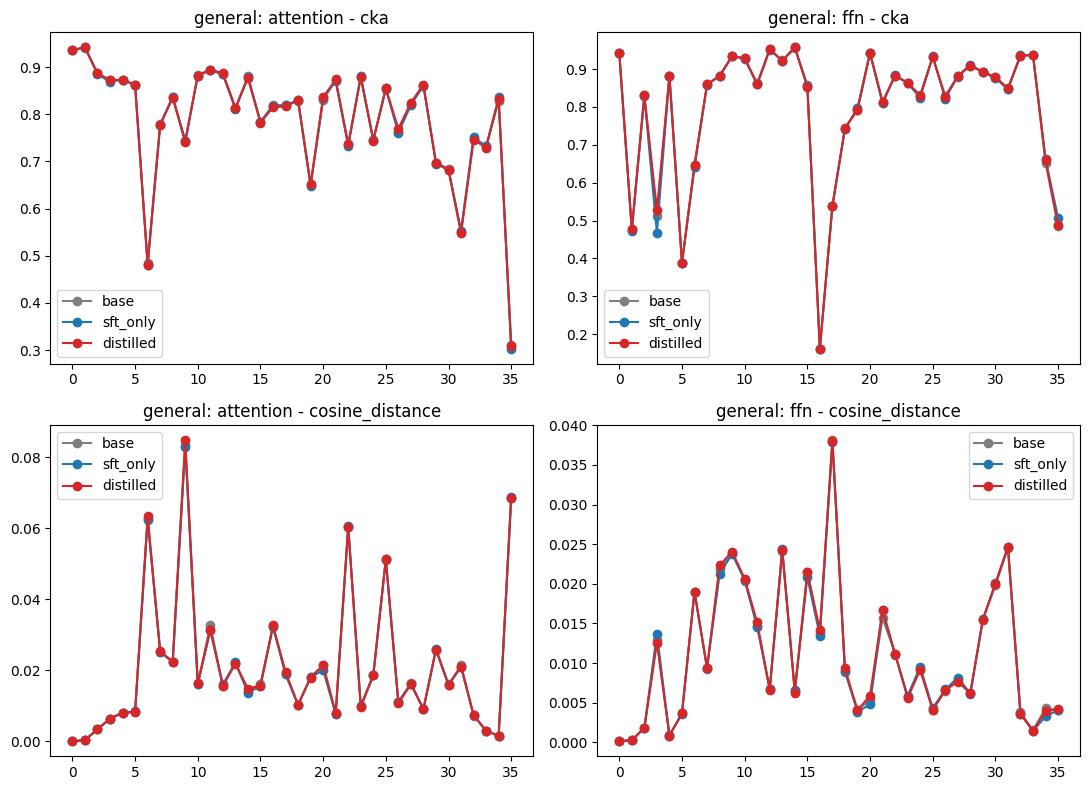

In [19]:
from adbench.analysis.layer_analysis import read_layer_analysis_results

la_config = experiment_config["layer_analysis"]
df = pd.DataFrame(read_layer_analysis_results(REPO_ROOT / la_config["results_path"]))
streams = ["attention", "ffn"]
metrics = la_config["divergence_metrics"]
colors = {"base": "tab:gray", "sft_only": "tab:blue", "distilled": "tab:red"}

for input_set in ["tool_use", "general"]:
    fig, axes = plt.subplots(len(metrics), len(streams), figsize=(11, 4 * len(metrics)), squeeze=False)
    for row_idx, metric in enumerate(metrics):
        for col_idx, stream in enumerate(streams):
            ax = axes[row_idx][col_idx]
            for condition, color in colors.items():
                sub = df[(df["stream"] == stream) & (df["input_set"] == input_set) & (df["condition"] == condition)].sort_values("source_layer")
                ax.plot(sub["source_layer"], sub[metric], marker="o", label=condition, color=color)
            ax.set_title(f"{input_set}: {stream} - {metric}")
            ax.legend()
    plt.tight_layout()
    plt.show()